## Term Deposit Subscription Prediction

In this task, we aim to predict whether a customer will subscribe to a term deposit using machine learning models.
We will compare multiple classification models and evaluate their performance using metrics like Accuracy, F1-score, Confusion Matrix, and ROC Curve.
We will also use SHAP to interpret model predictions.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



We explore the dataset to understand structure, data types, and distribution of the target variable.

In [34]:
from google.colab import files
uploaded = files.upload()



Saving bank.csv to bank (3).csv


In [35]:
import pandas as pd

df = pd.read_csv("bank.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


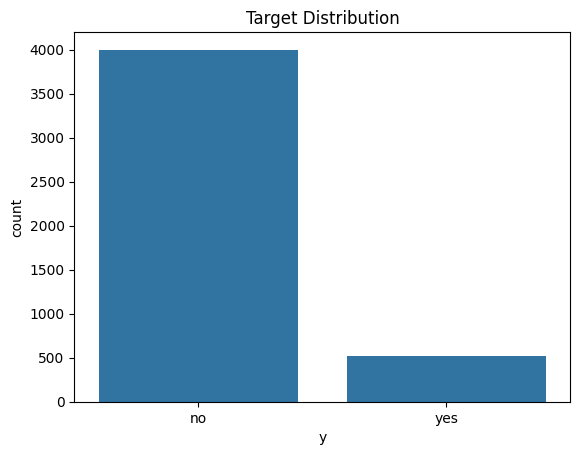

In [36]:
df.info()
df.isnull().sum()

sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

Categorical features are encoded into numerical values so that machine learning models can process them.

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

We split the dataset into training and testing sets for model evaluation.

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We train 5 different classification models and compare their performance.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

We evaluate each model using Accuracy and F1 Score.

In [40]:
from sklearn.metrics import accuracy_score, f1_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, f1])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy: 0.8883977900552487
F1 Score: 0.2518518518518518

Decision Tree
Accuracy: 0.8784530386740331
F1 Score: 0.4329896907216495

Random Forest
Accuracy: 0.9027624309392265
F1 Score: 0.38028169014084506

KNN
Accuracy: 0.8773480662983425
F1 Score: 0.3018867924528302

Naive Bayes
Accuracy: 0.8320441988950277
F1 Score: 0.36666666666666664


,Model,Accuracy,F1
0,Logistic Regression,0.888398,0.251852
1,Decision Tree,0.878453,0.432990
2,Random Forest,0.902762,0.380282
3,KNN,0.877348,0.301887
4,Naive Bayes,0.832044,0.366667


We analyze classification performance using confusion matrix.

In [41]:
from sklearn.metrics import confusion_matrix

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[787  20]
 [ 69  29]]


ROC Curve helps evaluate model performance across thresholds.

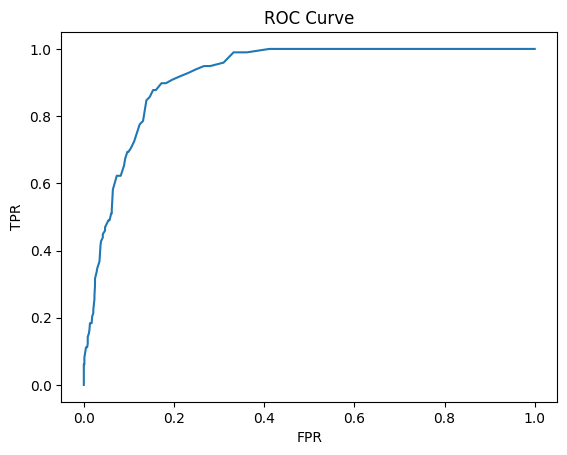

In [42]:
from sklearn.metrics import roc_curve

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

SHAP is used to interpret the model and understand feature importance.

In [43]:
!pip install shap


In [44]:
import shap

explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

100%|===================| 1802/1810 [00:49<00:00]       

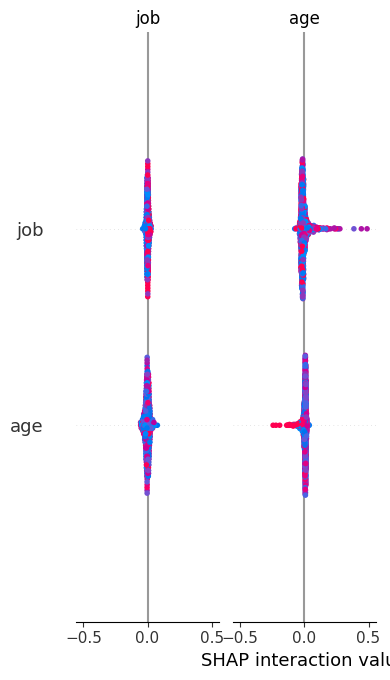

In [45]:
shap.summary_plot(shap_values.values, X_test)

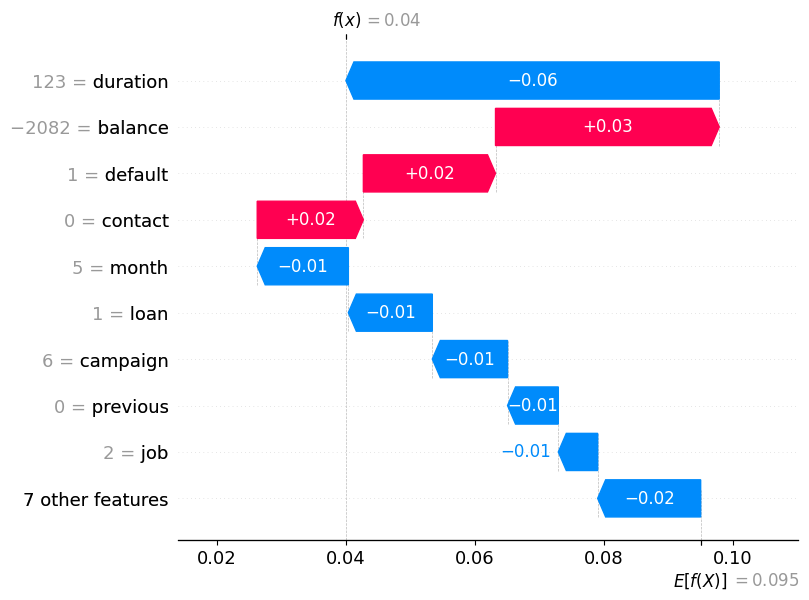


--- Sample 0: Prediction for Class 1 (Subscribed) ---



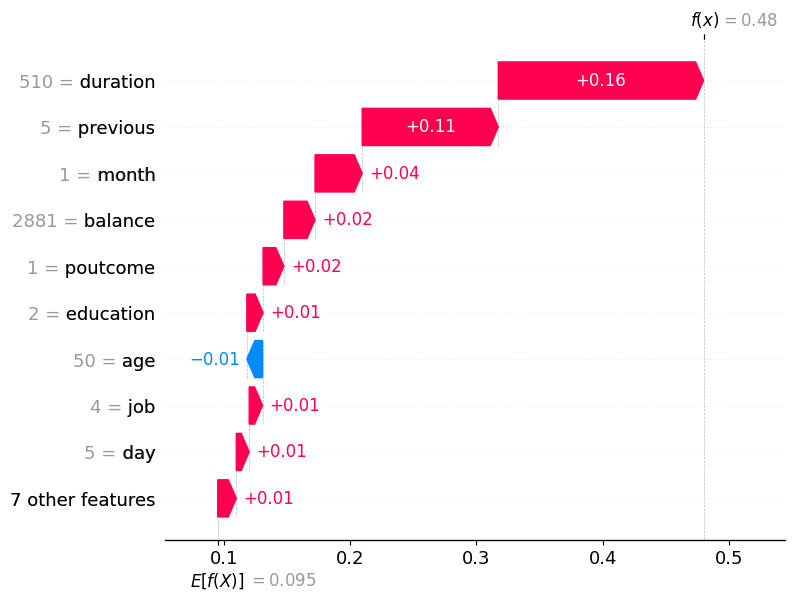


--- Sample 1: Prediction for Class 1 (Subscribed) ---



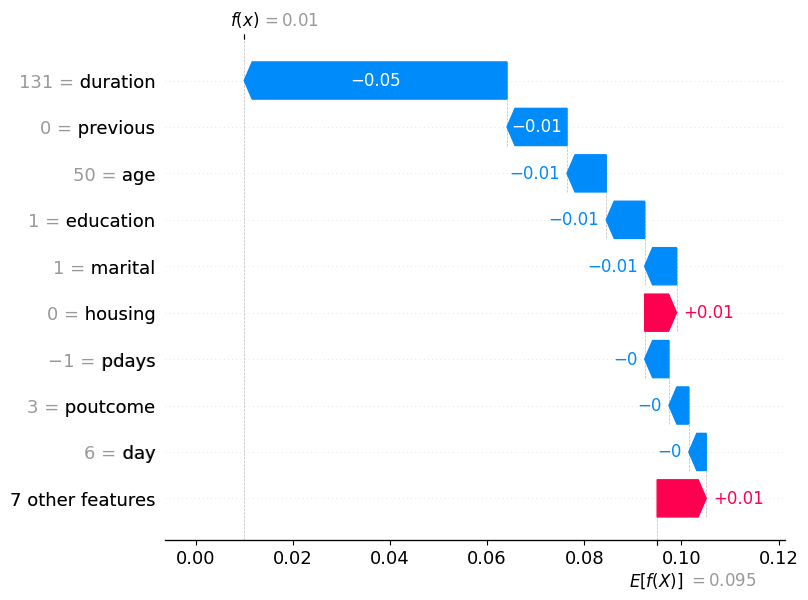


--- Sample 2: Prediction for Class 1 (Subscribed) ---



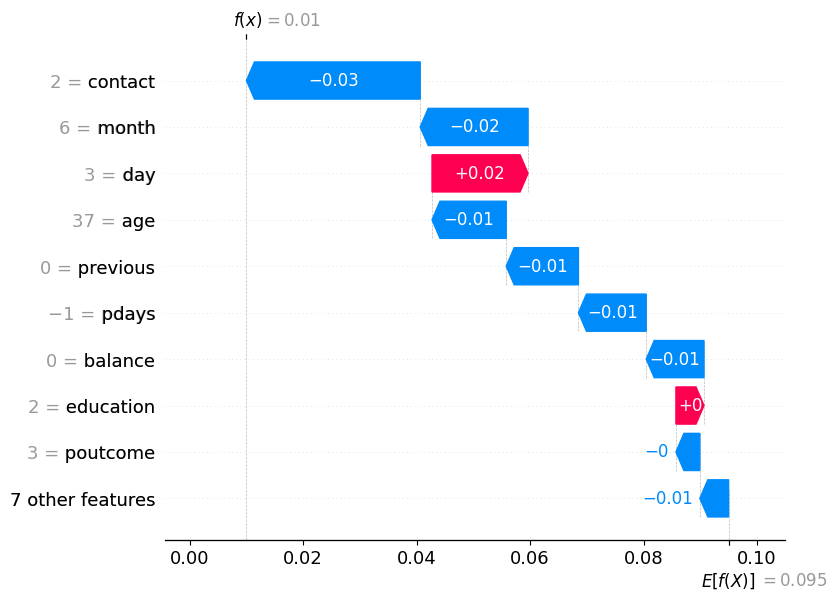


--- Sample 3: Prediction for Class 1 (Subscribed) ---



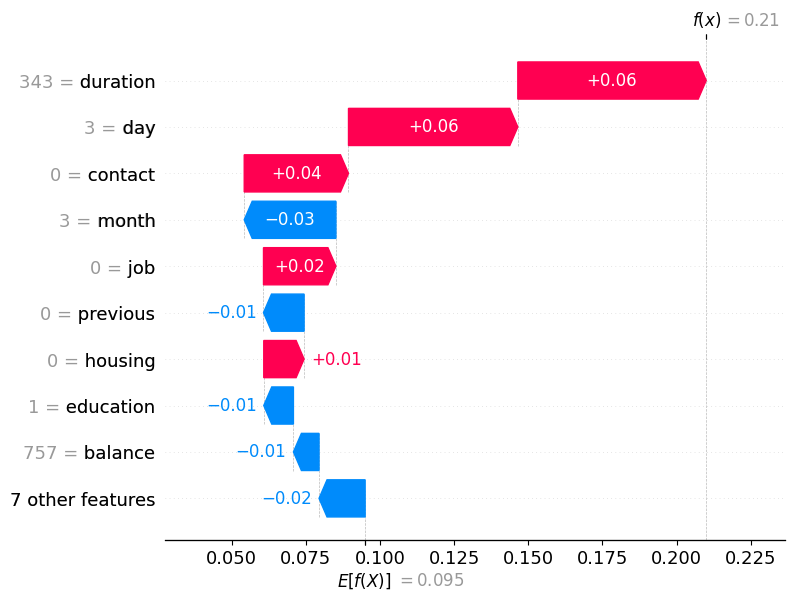


--- Sample 4: Prediction for Class 1 (Subscribed) ---



In [46]:
shap.initjs()

# For the positive class (customers who subscribed)
for i in range(5):
    shap.plots.waterfall(shap_values[i,:,1])
    print(f"\n--- Sample {i}: Prediction for Class 1 (Subscribed) ---\n")

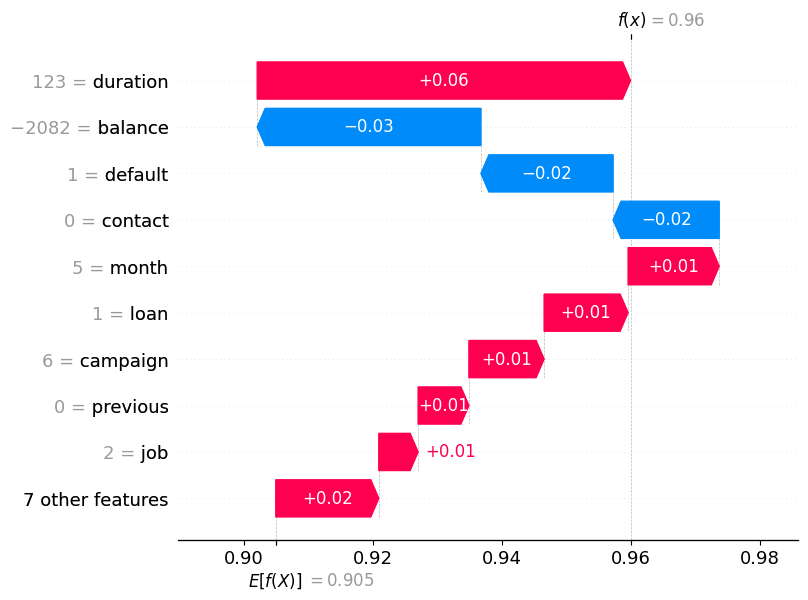


--- Sample 0: Prediction for Class 0 (Didn't Subscribe) ---



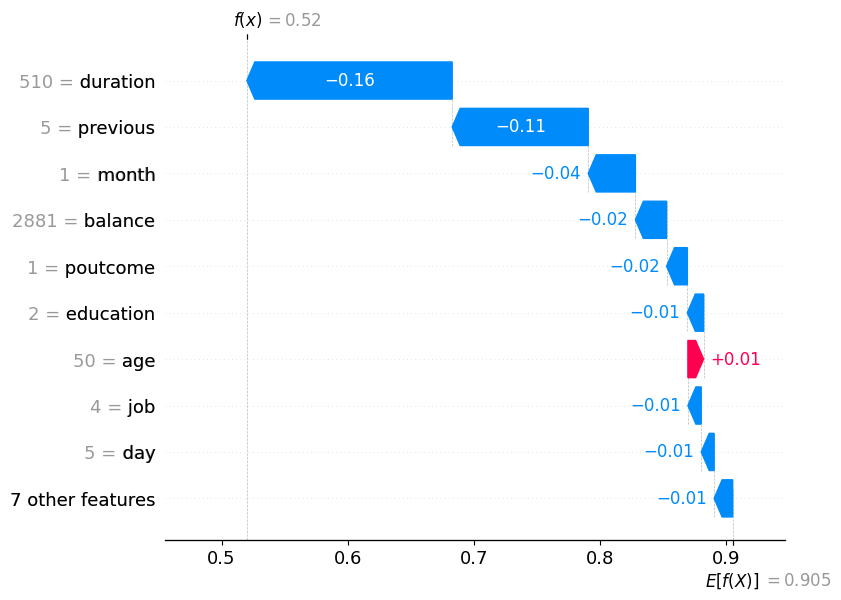


--- Sample 1: Prediction for Class 0 (Didn't Subscribe) ---



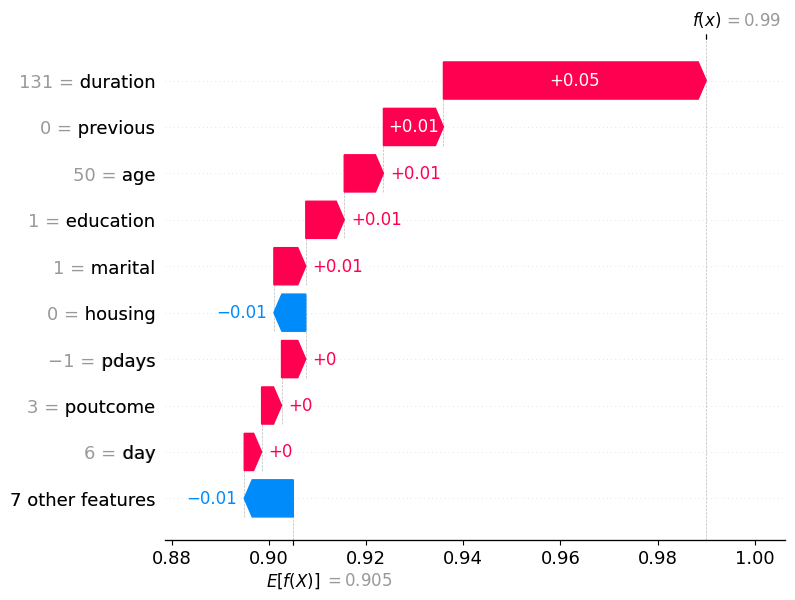


--- Sample 2: Prediction for Class 0 (Didn't Subscribe) ---



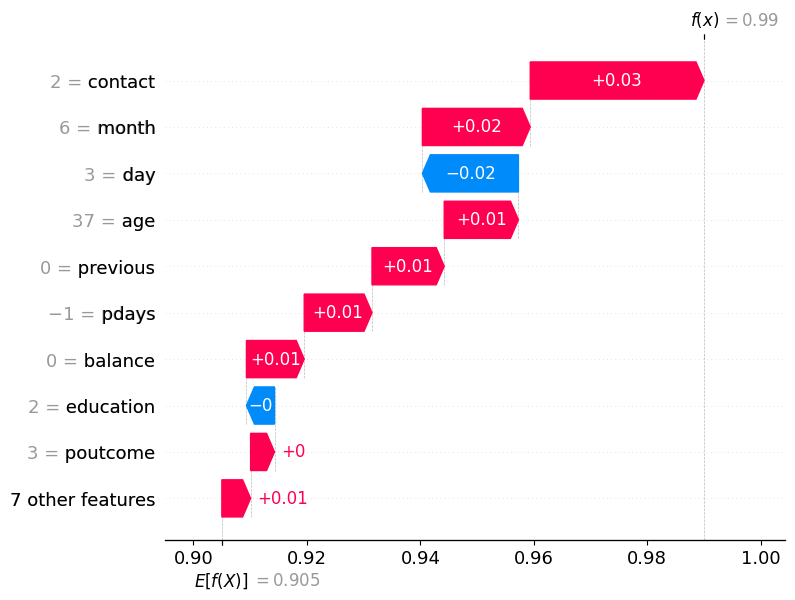


--- Sample 3: Prediction for Class 0 (Didn't Subscribe) ---



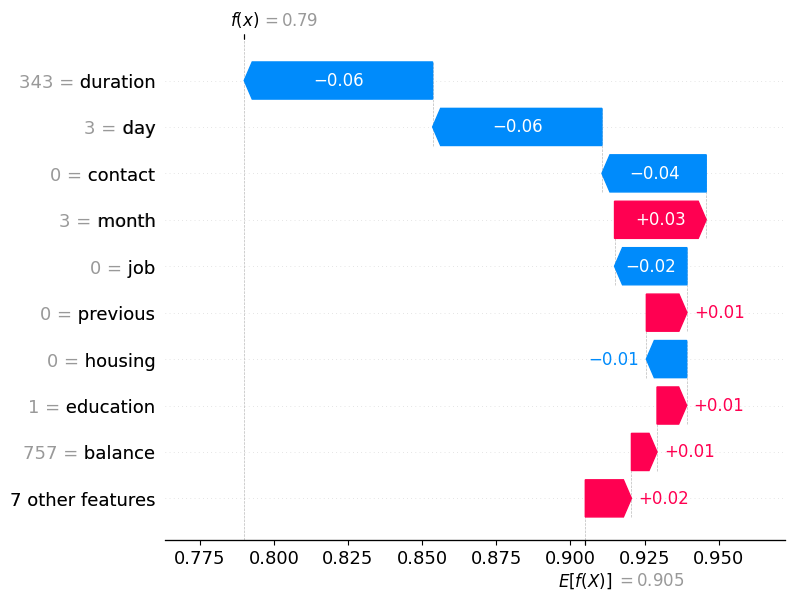


--- Sample 4: Prediction for Class 0 (Didn't Subscribe) ---



In [47]:
shap.initjs()
# For the negative class (customers who didn't subscribe)
for i in range(5):
    shap.plots.waterfall(shap_values[i, :, 0])
    print(f"\n--- Sample {i}: Prediction for Class 0 (Didn't Subscribe) ---\n")

## Conclusion

This project successfully built and compared multiple machine learning models to predict term deposit subscriptions. The **Random Forest** model achieved the highest accuracy (90%), while **SHAP** analysis highlighted key features like `duration`, `poutcome`, and `campaign` as the most influential drivers of customer decisions.

The combination of model evaluation and interpretability provides actionable insights for marketing strategies, demonstrating a complete and effective data science workflow.